In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


# Titanic Verisini Yükleme ve Temizleme
df = pd.read_csv("train.csv")  # CSV dosyasını oku

# Kullanılmayacak sütunları sil
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [2]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


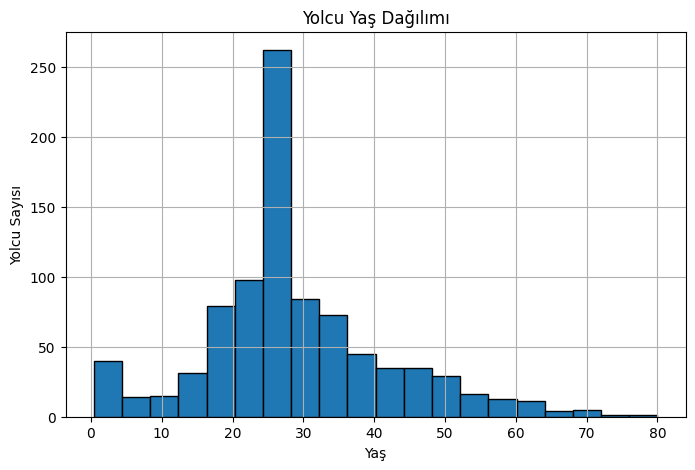

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20, edgecolor='black')
plt.title("Yolcu Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Yolcu Sayısı")
plt.grid(True)
plt.show()


In [8]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [9]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [10]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"C": 0, "Q": 1, "S": 2})

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,0,35.0,0,0,8.0500,2


In [12]:
scaler = MinMaxScaler()
df["Fare"] = scaler.fit_transform(df[["Fare"]])

In [13]:
X = torch.tensor(df.drop(columns=["Survived"]).values, dtype=torch.float32)
y = torch.tensor(df["Survived"].values, dtype=torch.float32).unsqueeze(1)  # (n,1) boyutuna getir

In [14]:
X.shape, y.shape

(torch.Size([891, 7]), torch.Size([891, 1]))

In [15]:
n_train = int(0.8 * len(X))  # %80 eğitim, %20 test
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

In [16]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([712, 7]),
 torch.Size([712, 1]),
 torch.Size([179, 7]),
 torch.Size([179, 1]))

In [17]:
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)

In [18]:
test_data = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

In [19]:
class TitanicCNN(nn.Module):
  def __init__(self, input_features, output_features, hidden_units):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Linear(input_features, hidden_units),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(hidden_units, hidden_units),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(hidden_units, output_features)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [20]:
model = TitanicCNN(7, 1, 32)
loss_fn = nn.BCEWithLogitsLoss()  # Sigmoid otomatik içinde
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [21]:
model

TitanicCNN(
  (layer_stack): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [22]:
epochs = 50
loss_values = []
for epoch in range(epochs):
    total_loss = 0.0
    model.train()
    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        y_pred = y_pred.view_as(y_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    loss_values.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1/50, Loss: 0.7184
Epoch 2/50, Loss: 0.6732
Epoch 3/50, Loss: 0.6672
Epoch 4/50, Loss: 0.6639
Epoch 5/50, Loss: 0.6609
Epoch 6/50, Loss: 0.6546
Epoch 7/50, Loss: 0.6487
Epoch 8/50, Loss: 0.6322
Epoch 9/50, Loss: 0.6159
Epoch 10/50, Loss: 0.6177
Epoch 11/50, Loss: 0.5924
Epoch 12/50, Loss: 0.6007
Epoch 13/50, Loss: 0.5757
Epoch 14/50, Loss: 0.5661
Epoch 15/50, Loss: 0.5628
Epoch 16/50, Loss: 0.5682
Epoch 17/50, Loss: 0.5618
Epoch 18/50, Loss: 0.5580
Epoch 19/50, Loss: 0.5374
Epoch 20/50, Loss: 0.5588
Epoch 21/50, Loss: 0.5479
Epoch 22/50, Loss: 0.5438
Epoch 23/50, Loss: 0.5234
Epoch 24/50, Loss: 0.5312
Epoch 25/50, Loss: 0.5246
Epoch 26/50, Loss: 0.5362
Epoch 27/50, Loss: 0.5199
Epoch 28/50, Loss: 0.5320
Epoch 29/50, Loss: 0.5053
Epoch 30/50, Loss: 0.5038
Epoch 31/50, Loss: 0.5391
Epoch 32/50, Loss: 0.5229
Epoch 33/50, Loss: 0.5233
Epoch 34/50, Loss: 0.5128
Epoch 35/50, Loss: 0.5167
Epoch 36/50, Loss: 0.5098
Epoch 37/50, Loss: 0.5050
Epoch 38/50, Loss: 0.5208
Epoch 39/50, Loss: 0.

In [23]:
import matplotlib.pyplot as plt

# Modeli değerlendirme moduna al
model.eval()

# Tahminleri ve gerçek etiketleri toplayacağımız listeler
all_preds = []
all_labels = []

with torch.inference_mode():
    for X_batch, y_batch in test_loader:
        y_out = model(X_batch)
        y_out = y_out.view_as(y_batch)
        y_pred = (y_out > 0.5).float()
        all_preds.extend(y_pred.squeeze().cpu().tolist())
        all_labels.extend(y_batch.squeeze().cpu().tolist())



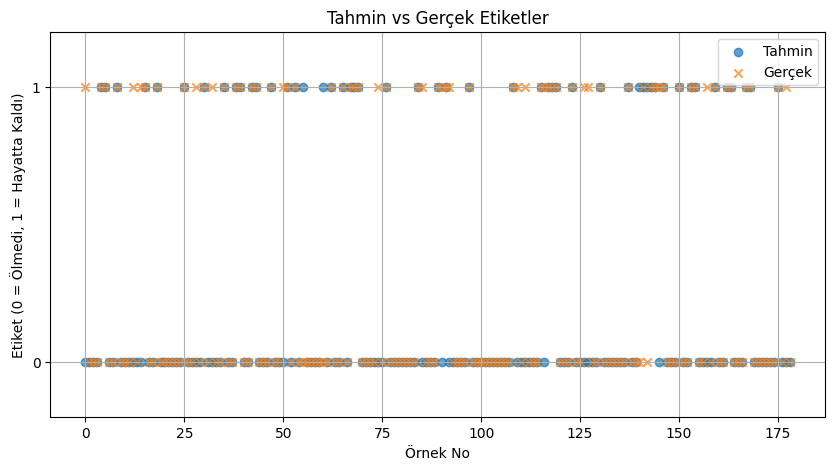

In [24]:
plt.figure(figsize=(10, 5))
plt.scatter(range(len(all_preds)), all_preds, label="Tahmin", alpha=0.7)
plt.scatter(range(len(all_labels)), all_labels, label="Gerçek", marker='x', alpha=0.7)
plt.yticks([0, 1])
plt.ylim(-0.2, 1.2)
plt.title("Tahmin vs Gerçek Etiketler")
plt.xlabel("Örnek No")
plt.ylabel("Etiket (0 = Ölmedi, 1 = Hayatta Kaldı)")
plt.legend()
plt.grid(True)
plt.show()


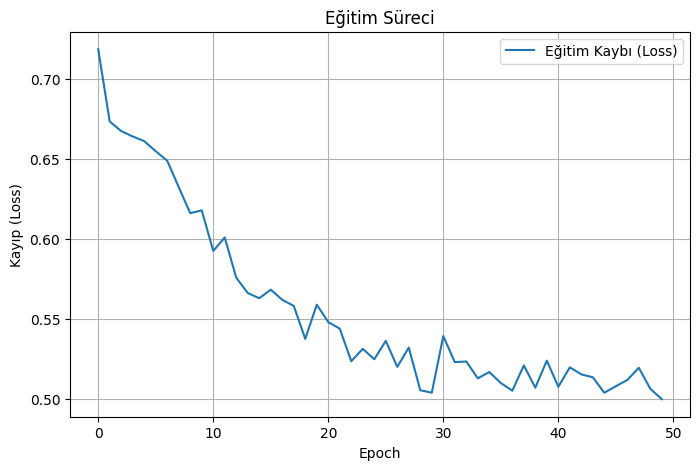

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(loss_values, label="Eğitim Kaybı (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Kayıp (Loss)")
plt.title("Eğitim Süreci")
plt.legend()
plt.grid(True)
plt.show()
